# **Single MD File Analysis Notebook**  

This notebook provides a structured workflow for analyzing a **single MD simulation file**, which can be either a **Long MD** or a **Single Aggregation** file. The analysis is conducted using modular Python scripts.

---

## Workflow Overview   

1. **Load Data** – Read simulation outputs from a selected `.bp` file.
2. **Analyze System Properties** – Compute system energy, temperature, and order parameters.
3. **Visualize Particle Configurations** – Generate snapshots and animations of particle distributions.
4. **Orientation Analysis** – Investigate particle orientation (\(\phi\)) and its variations.


---

## Part 1: Load Data & Extract Variables
- Read key variables and attributes from a selected simulation file.


In [10]:
import data_extraction
import system_analysis
import visualization

output_dir = "/home/hadis/selfassembly/runs/particleOriented/march12_testPara/outputs"
file_name = "/home/hadis/selfassembly/runs/particleOriented/april5_testChiralPot/outputs/run_0.bp"
file_name = "/home/hadis/selfassembly/run/tmpPatch/july23_patchy8/outputs/run_0.bp"
file_name = "/home/hadis/vector/output/Dec11_test/outputs/run_0.bp"
# data_extraction.print_output_info(file_name)


In [11]:
positions = data_extraction.read_variable(file_name, 'positions')
handedness = data_extraction.read_variable(file_name, 'handedness')
temperature = data_extraction.read_variable(file_name, 'real temperature')
kinetic_energy = data_extraction.read_variable(file_name,'kinetic energy')
potential_energy = data_extraction.read_variable(file_name,'potential energy')
number_of_neighbors = data_extraction.read_variable(file_name,'number of neighbors')
orientation_order = data_extraction.read_variable(file_name,'orientation order')

com_velocity = data_extraction.read_variable(file_name, 'center of mass velocity')
com_ang_velocity = data_extraction.read_variable(file_name, 'center of mass angular velocity')

temperature_label = data_extraction.read_attributes(file_name, 'temperature')
radius = data_extraction.read_attributes(file_name, 'radius')
areaL = data_extraction.read_attributes(file_name, 'areaL')

---

## Part 2: Kinetic Properties Analysis
- Plot system energy components (Kinetic, Potential, and Total).
- Analyze temperature distribution across different degrees of freedom (DOF).
- Compute and visualize **positional** and **orientational order**.
- Examine **linear** and **angular velocity** of the center of mass (COM).


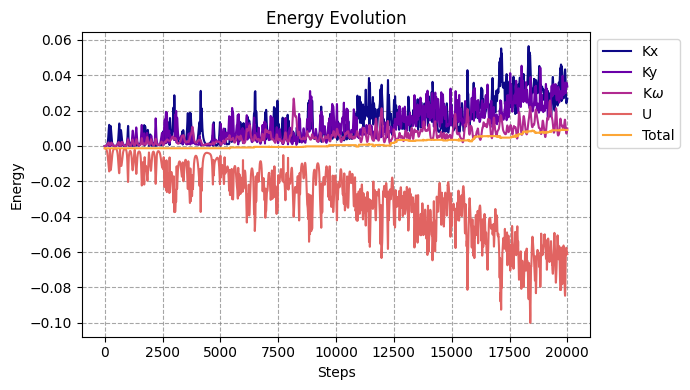

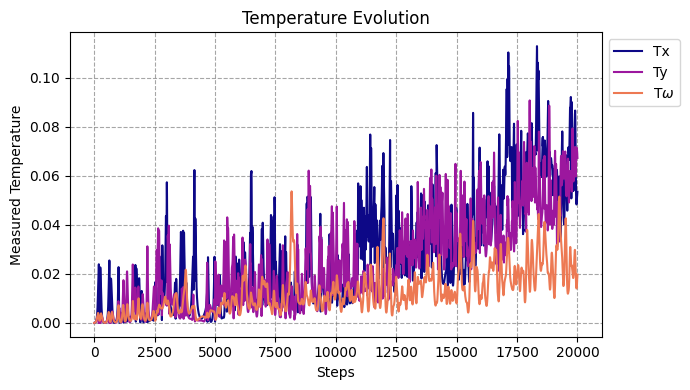

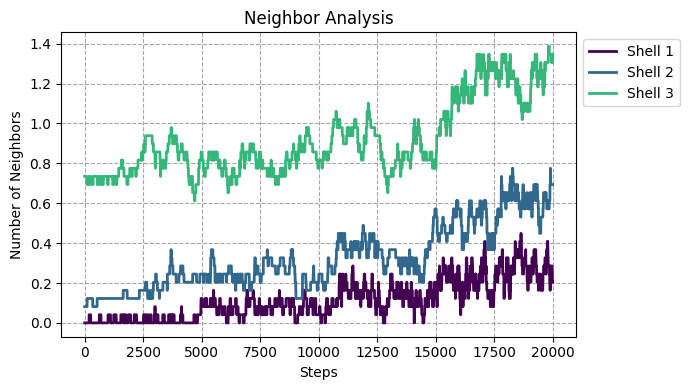

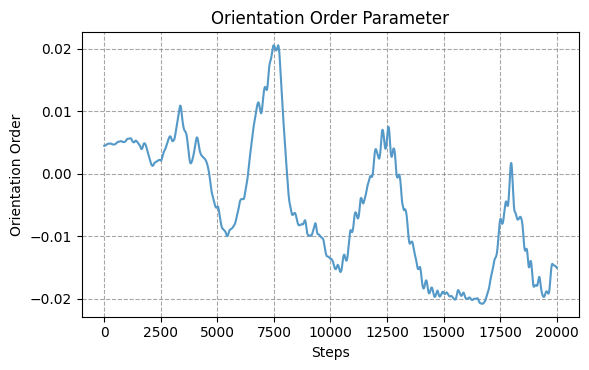

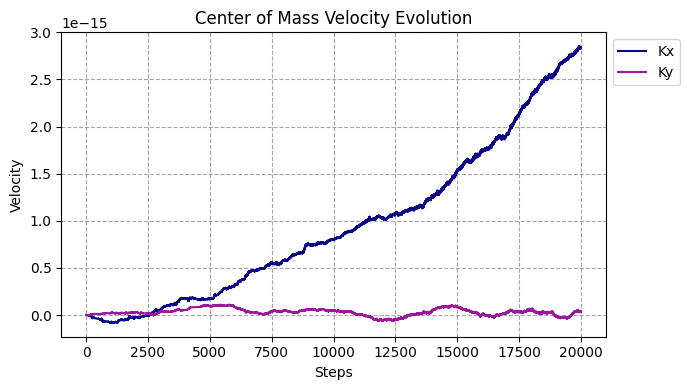

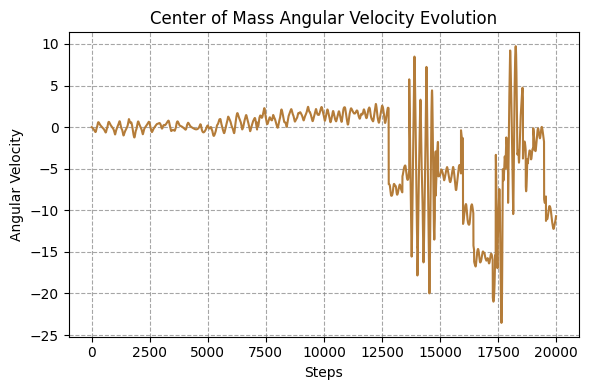

In [12]:
visualization.plot_energies(kinetic_energy, potential_energy, temperature, show_potential=True, temperature_label=False, plot_window=20000)
visualization.plot_temperature(temperature)
visualization.plot_neighbors(number_of_neighbors, temperature)
visualization.plot_order_parameter(orientation_order, temperature)
visualization.plot_com_velocity(com_velocity, temperature)
visualization.plot_com_ang_velocity(com_ang_velocity, temperature)

---

## Part 3: Particle Configuration Visualization
- **Snapshot** of particle positions at a selected simulation step.
- **Animation** of particle configuration evolution over time.
- **Particle Trajectories** for a specific range of steps.



In [ ]:

visualization.plot_configuration(positions, handedness, step_target=-1, radius=0.4, color_phi=False, diameter=80, 
                                x_limit=(0, 20),y_limit=(0, 20), aggregation=False, 
                                save_fig=False, save_name='output.pdf', 
                                set_title=None)

In [ ]:
visualization.plot_trajectory_steps(positions, step_target=17000, step_window=1900, area=20)

---
* create **animation** of particles movement over the simulation:

In [ ]:
visualization.animate_position_simple(positions, "patchySingle4_all.mp4", area=20, frame_skip=10, fps=60, patchNums=4)

---

## Part 4: Orientational Analysis
- Evolution of **particle orientations** ($\phi$) over simulation steps.
- Analysis of **angular displacements** ($\Delta \phi$) to examine rotational dynamics.


In [ ]:
visualization.plot_hist_phi_steps(positions, step_target=1000, step_window=2000)

In [ ]:
visualization.plot_deltaphi_hist_steps(positions, step_target=1000, step_window=100)